# Pathspace Lab MVP

Pathspace Lab is a living tutorial for comparing three mechanisms on one layered path-DP problem:

- Hard DP as deterministic min-plus message passing.
- Soft-DP as a classical thermal distribution over complete paths.
- Feasible-subspace QA as coherent Hamiltonian evolution over feasible complete paths.

The heatmaps in this notebook will share a coordinate system, not a mechanism. DP values, Soft-DP probabilities, and QA amplitudes live in different hidden spaces and are only projected onto the same layer-node canvas for comparison.

In [1]:
from pathlib import Path
import sys

for candidate_root in (Path.cwd(), Path.cwd().parent):
    src_path = candidate_root / "src"
    if src_path.exists():
        sys.path.insert(0, str(src_path.resolve()))
        break

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pathspace_lab

print("Pathspace Lab import OK")
print(f"Pathspace Lab version: {pathspace_lab.__version__}")

Pathspace Lab import OK
Pathspace Lab version: 0.1.0


## Setup and Reproducibility

The notebook will grow issue by issue. Implementation logic belongs in `src/pathspace_lab`; notebook cells should import reusable package functions, display small diagnostics, and explain what each figure means.

Later sections are present now as placeholders so each future issue has a stable narrative home. Pending sections intentionally contain markdown only until their corresponding backend code exists.

In [2]:
component_status = pd.DataFrame(
    [
        {
            "Component": "Project package scaffold",
            "Status": "Implemented",
            "First issue": "00",
            "Notebook role": "Imports `pathspace_lab` from the package.",
        },
        {
            "Component": "Living notebook harness",
            "Status": "Implemented",
            "First issue": "00A",
            "Notebook role": "Provides the runnable tutorial skeleton.",
        },
        {
            "Component": "PathDPProblem protocol and traces",
            "Status": "Implemented",
            "First issue": "01",
            "Notebook role": "Demonstrate the shared data contract.",
        },
        {
            "Component": "LayeredDAGProblem",
            "Status": "Implemented",
            "First issue": "02",
            "Notebook role": "Create the first real layered path instance.",
        },
        {
            "Component": "Hard DP",
            "Status": "Pending",
            "First issue": "04",
            "Notebook role": "Show deterministic min-plus values and traceback.",
        },
        {
            "Component": "Soft-DP",
            "Status": "Pending",
            "First issue": "05",
            "Notebook role": "Show thermal path probabilities and marginals.",
        },
        {
            "Component": "Feasible-subspace QA",
            "Status": "Pending",
            "First issue": "06-07",
            "Notebook role": "Show Hamiltonian objects and amplitude evolution.",
        },
        {
            "Component": "Visualizers",
            "Status": "Pending",
            "First issue": "08-11",
            "Notebook role": "Replace diagnostics with reusable figures.",
        },
    ]
)

component_status

,Component,Status,First issue,Notebook role
0,Project package scaffold,Implemented,00,Imports `pathspace_lab` from the package.
1,Living notebook harness,Implemented,00A,Provides the runnable tutorial skeleton.
2,PathDPProblem protocol and traces,Implemented,01,Demonstrate the shared data contract.
3,LayeredDAGProblem,Implemented,02,Create the first real layered path instance.
4,Hard DP,Pending,04,Show deterministic min-plus values and traceback.
5,Soft-DP,Pending,05,Show thermal path probabilities and marginals.
6,Feasible-subspace QA,Pending,06-07,Show Hamiltonian objects and amplitude evolution.
7,Visualizers,Pending,08-11,Replace diagnostics with reusable figures.


## Create a Planted Layered Path Problem

We now build the first real problem instance. A visible path chooses exactly one node per layer, so a problem with `L` layers and `W` choices per layer has `W ** L` feasible paths.

The generator plants two named paths. The gold path is globally optimal, but the decoy path has the cheaper early prefix and then pays a late transition penalty. That tension is deliberate: later probability plots can show how local attraction and global optimality separate.

In [3]:
from pathspace_lab.problems.layered_dag import make_planted_layered_problem

problem = make_planted_layered_problem(L=5, W=3, seed=7)
paths = problem.enumerate_paths()
energies = np.array([problem.path_energy(path) for path in paths])
best_index = int(energies.argmin())
best_path = paths[best_index]

gold_path = problem.metadata["gold_path"]
decoy_path = problem.metadata["decoy_path"]

print("num paths:", len(paths))
print("expected:", problem.W**problem.L)
print("best energy:", float(energies[best_index]))
print("best path:", best_path)
print("gold path:", gold_path)
print("decoy path:", decoy_path)
print("gold energy:", problem.metadata["gold_energy"])
print("decoy energy:", problem.metadata["decoy_energy"])
print("gold prefix energy:", problem.metadata["gold_prefix_energy"])
print("decoy prefix energy:", problem.metadata["decoy_prefix_energy"])

num paths: 243
expected: 243
best energy: 5.969999999999999
best path: ((0, 1), (1, 1), (2, 0), (3, 0), (4, 1))
gold path: ((0, 1), (1, 1), (2, 0), (3, 0), (4, 1))
decoy path: ((0, 2), (1, 2), (2, 1), (3, 1), (4, 2))
gold energy: 5.969999999999999
decoy energy: 8.46
gold prefix energy: 3.9100000000000006
decoy prefix energy: 1.21


In [4]:
problem_summary = pd.DataFrame(
    [
        {
            "quantity": "visible layers",
            "value": problem.L,
            "note": "source and sink are hidden from heatmaps",
        },
        {
            "quantity": "nodes per layer",
            "value": problem.W,
            "note": "fixed width in the MVP",
        },
        {
            "quantity": "feasible paths",
            "value": len(paths),
            "note": "equals W ** L",
        },
        {
            "quantity": "gold energy",
            "value": round(problem.metadata["gold_energy"], 3),
            "note": "global optimum by construction",
        },
        {
            "quantity": "decoy energy",
            "value": round(problem.metadata["decoy_energy"], 3),
            "note": "cheap prefix, late trap",
        },
    ]
)

problem_summary

,quantity,value,note
0,visible layers,5.00,source and sink are hidden from heatmaps
1,nodes per layer,3.00,fixed width in the MVP
2,feasible paths,243.00,equals W ** L
3,gold energy,5.97,global optimum by construction
4,decoy energy,8.46,"cheap prefix, late trap"


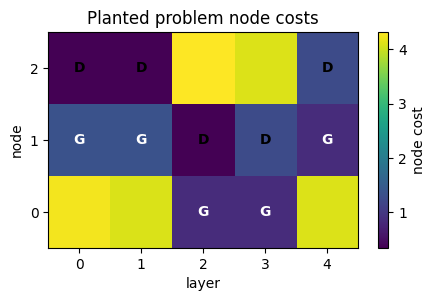

In [5]:
fig, ax = plt.subplots(figsize=(5.0, 2.8))
image = ax.imshow(problem.node_cost.T, origin="lower", aspect="auto")
ax.set_title("Planted problem node costs")
ax.set_xlabel("layer")
ax.set_ylabel("node")
ax.set_xticks(range(problem.L))
ax.set_yticks(range(problem.W))

for ell, v in gold_path:
    ax.text(ell, v, "G", ha="center", va="center", color="white", weight="bold")
for ell, v in decoy_path:
    ax.text(ell, v, "D", ha="center", va="center", color="black", weight="bold")

fig.colorbar(image, ax=ax, label="node cost")
plt.show()

The node-cost heatmap only shows the per-layer selection costs. It does not show transition costs, which is exactly where the decoy's late penalty is hidden. Source and sink are useful for graph algorithms, but the shared canvas for later DP, Soft-DP, and QA projections is only the visible `(layer, node)` grid.

## The Data Contract

`Frame` and `SolverTrace` are the shared output shape for solvers and visualizers. A frame is one snapshot at a progress value. A trace is an ordered list of frames for one method on one problem.

The example below is deliberately dummy data. It checks the contract before any real solver exists.

In [ ]:
from pathspace_lab.utils.typing import Frame, SolverTrace

toy_heat = np.ones((2, 3)) / 3
frame = Frame(progress=0.0, label="toy", cell_heat=toy_heat)
trace = SolverTrace(method="toy", problem_name="toy", frames=[frame])

print(trace.method, len(trace.frames), trace.frames[0].cell_heat.shape)

fig, ax = plt.subplots(figsize=(3.5, 2.4))
image = ax.imshow(frame.cell_heat.T, origin="lower", aspect="auto", vmin=0.0, vmax=1.0)
ax.set_title("Toy Frame.cell_heat")
ax.set_xlabel("layer")
ax.set_ylabel("node")
fig.colorbar(image, ax=ax, label="dummy marginal")
plt.show()

## Hard DP as Deterministic Message Passing

Pending implementation.

This section will show min-plus DP values, explain that DP compresses histories into local scalar values, and compare the traceback path with brute force enumeration.

## Soft-DP as Classical Thermal Condensation

Pending implementation.

This section will turn path energies into Boltzmann probabilities, then project those complete-path probabilities onto layer-node marginals.

## Feasible-Subspace QA

Pending implementation.

This section will build the feasible-subspace QA proxy: basis states are complete feasible paths, the driver ground state is uniform over feasible paths, and the problem Hamiltonian is diagonal in path energies.

## Same Projection, Different Dynamics

Pending implementation.

This section will compare Soft-DP and QA on the same layer-node canvas by progress and by matched entropy. The shared heatmap is a projection, not evidence that the hidden mechanisms are the same.

## Observable Dashboard

Pending implementation.

This section will track expected energy, residual energy, entropy, effective number of paths, success probability, and QA spectral gap when available.

## Flow vs Current

Pending implementation.

This section will contrast Soft-DP probability flow on the original DAG with QA probability current on the graph of complete paths. QA current must not be drawn as if it flows along the original problem edges.

## Summary, Limitations, and Roadmap

Pending implementation.

The MVP is a teaching model, not a quantum advantage claim, not a D-Wave hardware simulation, and not a generic QUBO transverse-field annealer. Future sections will keep those boundaries explicit while the notebook becomes more visual and more computationally complete.